# Ejercicio Python de Regresión Logística
Realizaremos un ejercicio de prueba para comprender como funciona este algoritmo

In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Cargamos los datos de entrada del archivo csv

In [2]:
dataframe = pd.read_csv("data/usuarios_win_mac_lin.csv")

clases = {
    0: 'Windows',
    1: 'Linux',
    2: 'Mac'
}

dataframe

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2
...,...,...,...,...,...
165,13.0,1,7,42,0
166,12.0,1,2,6,0
167,13.0,1,3,9,0
168,13.0,1,7,28,0


Clasificación multiclase.

El target es la variable clase.

Vemos si los datos estan equilibrados.

In [3]:
dataframe['clase'].value_counts(normalize=True)

clase
0    0.505882
2    0.258824
1    0.235294
Name: proportion, dtype: float64

In [4]:
dataframe.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


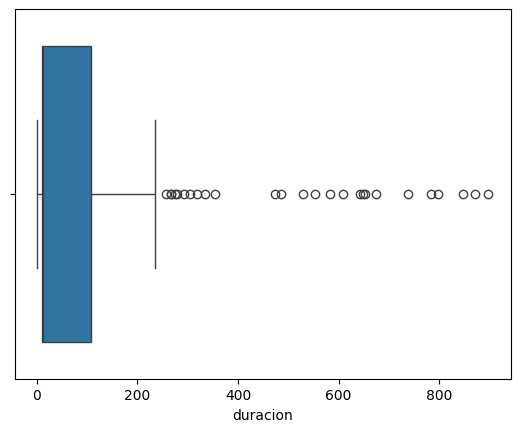

In [5]:
sns.boxplot(x= dataframe['duracion']);

In [6]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [7]:
print(dataframe.groupby('clase').size())

clase
0    86
1    40
2    44
dtype: int64


## Visualizamos los datos

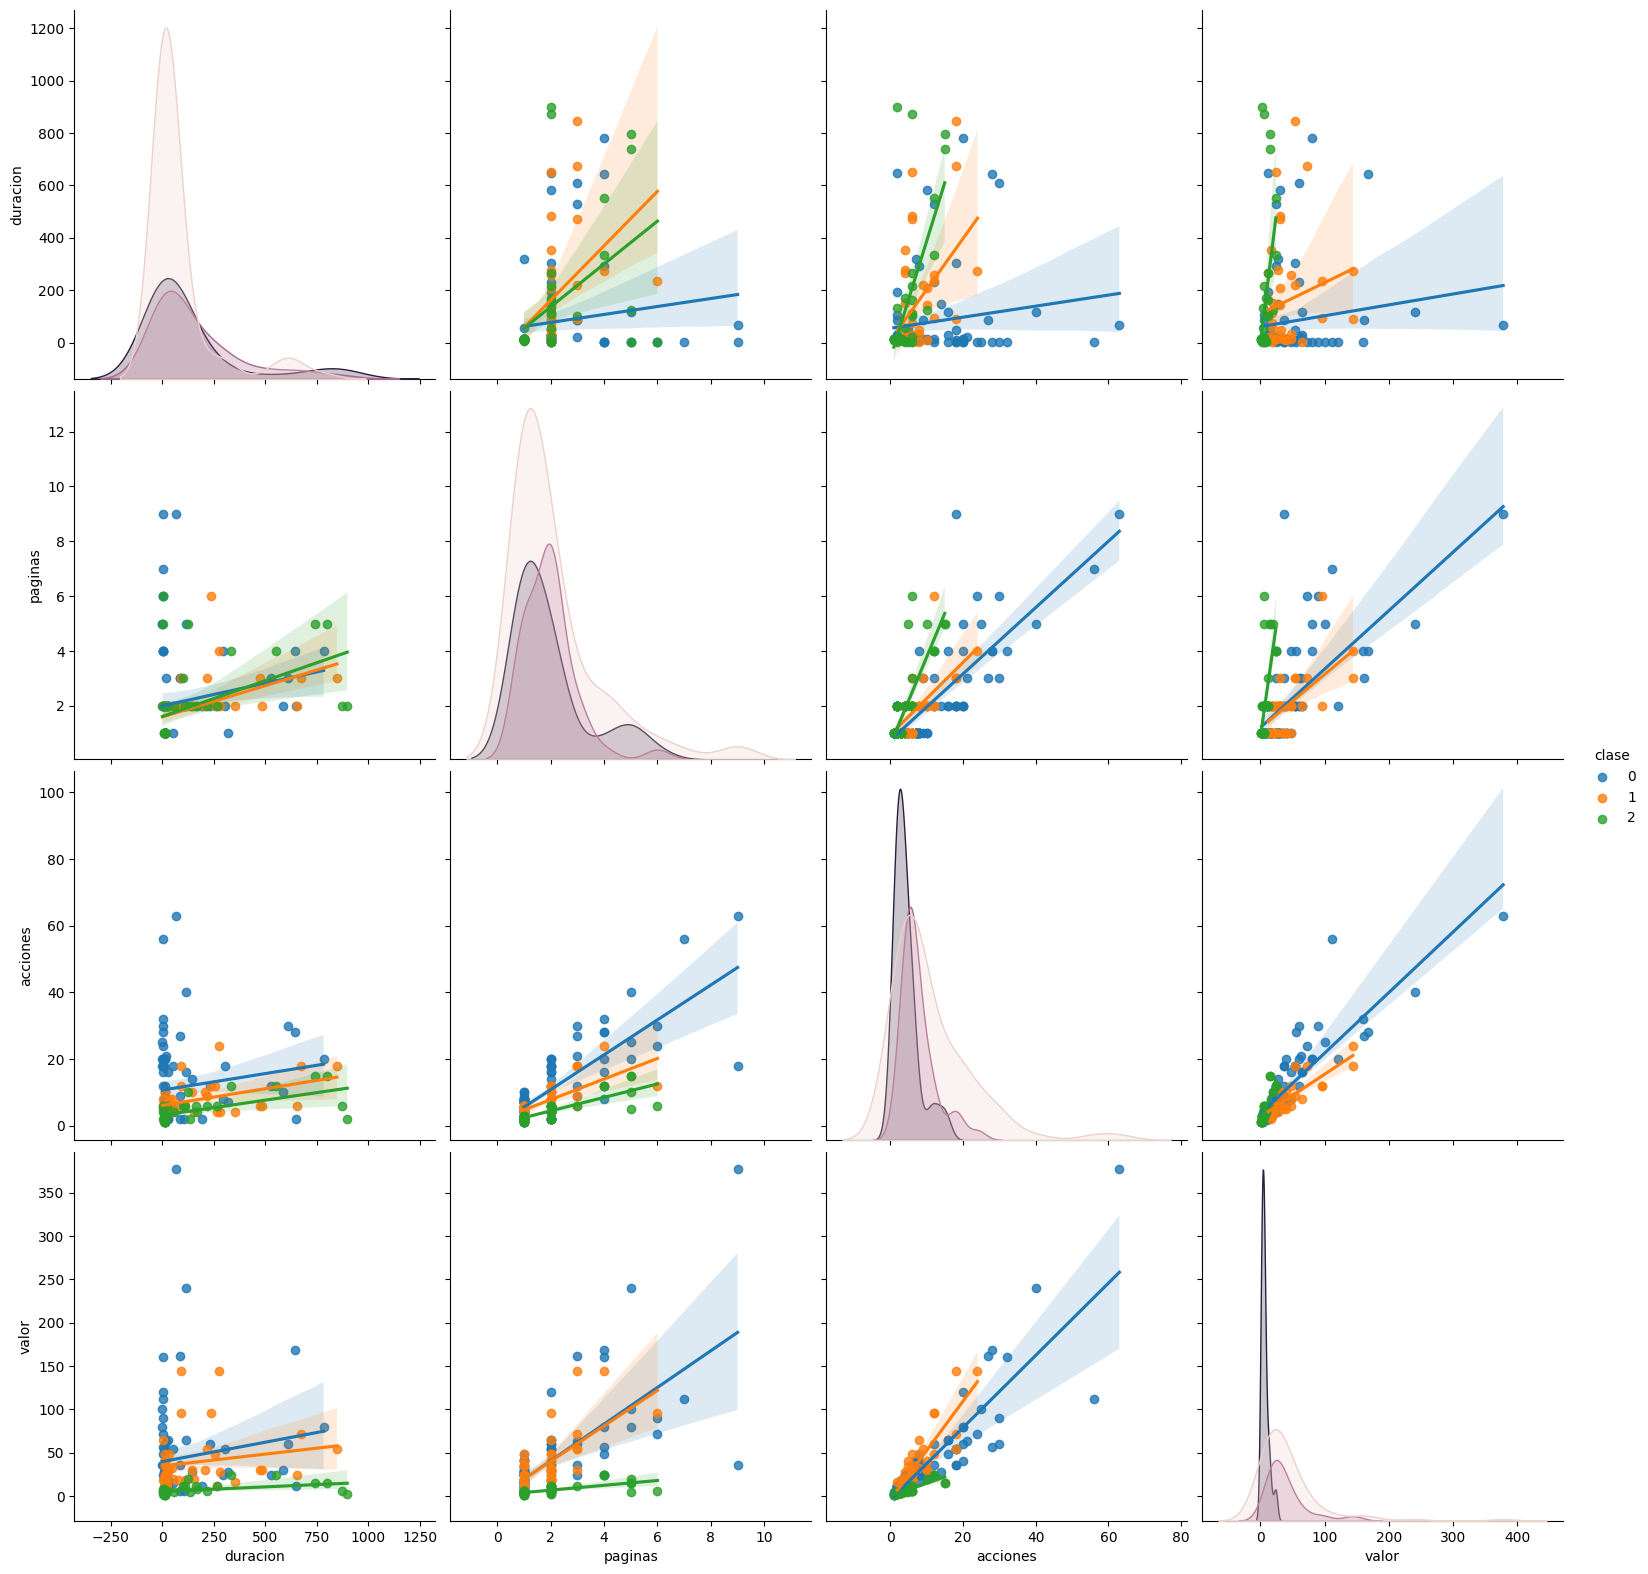

In [8]:
# Cuando tenemos un target que es una variable de clasificación, los datos se tiene que identificar por clase (hue='clase')
sns.pairplot(dataframe.dropna(),
            hue='clase',
            height=4,
            vars=["duracion", "paginas","acciones","valor"],
            kind='reg'); # "reg" de regresión lineal

<Axes: >

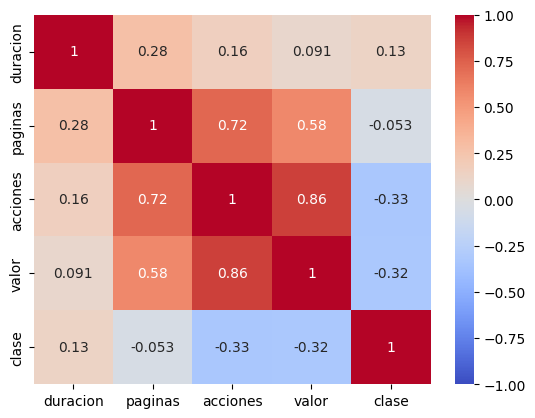

In [9]:
sns.heatmap(dataframe.corr(), annot=True, vmin = -1, cmap="coolwarm")

## Creamos el modelo

In [11]:
X = np.array(dataframe.drop(columns=['clase']))
y = np.array(dataframe['clase'])

In [12]:
X

array([[  7.   ,   2.   ,   4.   ,   8.   ],
       [ 21.   ,   2.   ,   6.   ,   6.   ],
       [ 57.   ,   2.   ,   4.   ,   4.   ],
       [101.   ,   3.   ,   6.   ,  12.   ],
       [109.   ,   2.   ,   6.   ,  12.   ],
       [125.   ,   5.   ,  10.   ,  20.   ],
       [133.   ,   2.   ,   2.   ,   4.   ],
       [162.   ,   2.   ,   6.   ,  12.   ],
       [170.   ,   2.   ,   4.   ,   8.   ],
       [217.   ,   2.   ,   6.   ,   6.   ],
       [266.   ,   2.   ,   6.   ,  12.   ],
       [335.   ,   4.   ,  12.   ,  24.   ],
       [553.   ,   4.   ,  12.   ,  24.   ],
       [798.   ,   5.   ,  15.   ,  15.   ],
       [872.   ,   2.   ,   6.   ,   6.   ],
       [  1.105,   2.   ,   4.   ,   8.   ],
       [  2.091,   5.   ,   5.   ,   5.   ],
       [ 21.   ,   2.   ,   4.   ,  12.   ],
       [ 33.   ,   2.   ,   8.   ,  48.   ],
       [ 49.   ,   2.   ,   8.   ,  32.   ],
       [ 74.   ,   2.   ,   6.   ,  18.   ],
       [ 93.   ,   2.   ,  12.   ,  96.   ],
       [14

Este modelo se basa en una representación lineal

In [13]:
from sklearn.linear_model import LogisticRegression

Max_uter permite aumentar el numero de iteraciones:

- más iteraciones, dura mas, mas precision

- menos iteraciones, dura menos, menos precision




In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Max_iter es el parámetro que nos permite aumentar el número de iteraciones.

- Menos iteraciones, tarda menos pero se ajusta menos y la calidad de las predicciones puede bajar.

- Más iteraciones, tarda más. Puede sobre ajustar el modelo.

In [ ]:
y

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [15]:
predictions = model.predict(X)
print(predictions)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 2 2
 2 2 2 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1 0 0 0 0 2 0
 0 1 1 1 0 0 0 0 0 0 0 0 2 1 0 0 0 0 1 0 0 2 0 2 1 0 0 0 0 0 0 0 0 0 0 1 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0
 0 0 0 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 0]


Predict_proba() nos devuelve las probabilidad de pertenecer a cada clase.

In [17]:
predicions_proba = model.predict_proba(X)
print(np.round(np.array(predicions_proba), 2))

[[0.22 0.09 0.69]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.18 0.08 0.74]
 [0.28 0.1  0.62]
 [0.27 0.08 0.65]
 [0.05 0.05 0.91]
 [0.22 0.09 0.69]
 [0.09 0.06 0.84]
 [0.   0.   1.  ]
 [0.12 0.07 0.8 ]
 [0.32 0.09 0.59]
 [0.1  0.06 0.84]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.23 0.09 0.68]
 [0.   0.   1.  ]
 [0.65 0.34 0.01]
 [0.58 0.42 0.  ]
 [0.73 0.27 0.  ]
 [0.71 0.29 0.  ]
 [0.32 0.68 0.  ]
 [0.82 0.18 0.  ]
 [0.46 0.54 0.  ]
 [0.78 0.22 0.  ]
 [0.37 0.63 0.  ]
 [0.09 0.91 0.  ]
 [0.72 0.28 0.  ]
 [0.45 0.52 0.03]
 [0.5  0.5  0.  ]
 [0.35 0.65 0.  ]
 [0.22 0.78 0.  ]
 [0.26 0.74 0.  ]
 [0.22 0.78 0.  ]
 [0.64 0.36 0.  ]
 [0.01 0.   0.99]
 [0.03 0.02 0.95]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.   0.   1.  ]
 [0.81 0.19 0.  ]
 [0.61 0.39 0.  ]
 [0.54 0.46 0.  ]
 [0.23 0.77 0.  ]
 [0.68 0.32 0.  ]
 [0.28 0.72 0.  ]
 [0.57 0.43 0.  ]
 [0.41 0.59 0.  ]
 [0.76 0.24 0.  ]
 [0.99 0.01 0.  ]
 [0.77 0.23 0.  ]
 [0.78 0.22 0.  ]
 [0.97 0.03 0.  ]
 [0.99 0.01 0.  ]
 [0.91 0.09 0.  ]
 [0.98 0.0

In [18]:
predicions_proba.shape

(170, 3)

In [19]:
model.score(X, y)

0.7764705882352941

In [20]:
model.classes_

array([0, 1, 2])

# Validación del Modelo

In [22]:
validation_size = 0.20
seed = 10
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X,
                                                                    y,
                                                                    test_size=validation_size,
                                                                    random_state=seed)

# Modelo básico de clasificación
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)
pred = lr.predict(X_test)

print("Accuract:", accuracy_score(Y_test, pred))
print(confusion_matrix(Y_test, pred))
      

Accuract: 0.6764705882352942
[[13  1  0]
 [10  2  0]
 [ 0  0  8]]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

           0       0.57      0.93      0.70        14
           1       0.67      0.17      0.27        12
           2       1.00      1.00      1.00         8

    accuracy                           0.68        34
   macro avg       0.74      0.70      0.66        34
weighted avg       0.70      0.68      0.62        34



<Axes: >

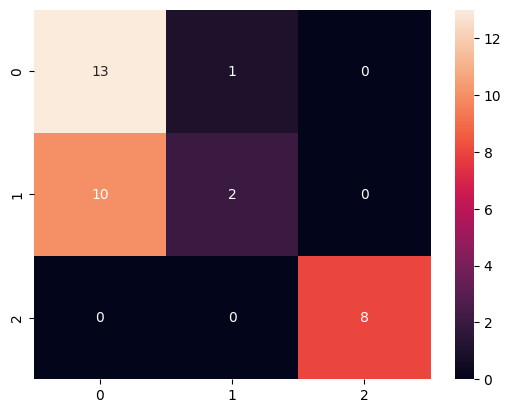

In [24]:
c_matrix = confusion_matrix(Y_test, pred)
sns.heatmap(c_matrix, annot=True)

## VALIDACIÓN CRUZADA - CROSS VALIDATION

Sirve para evaluar la calidad de nuestros datos.

In [54]:
name='Logistic Regression'
# PARTIMOS EN 10 PAQUETES, EL NUMERO DE INTERACIONES CORRESPONDE CON EL NUMERO DE PAQUETES
kfold = model_selection.KFold(n_splits=10) #Parte los datos en 10 trozos para usar validación cruzada / cross validation
cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')

msg =  (name, cv_results.mean(), cv_results.std())
print(cv_results)
print("____________________________________")
print(msg)

[0.85714286 0.71428571 0.64285714 0.85714286 0.64285714 0.57142857
 0.84615385 0.76923077 0.76923077 0.84615385]
____________________________________
('Logistic Regression', np.float64(0.7516483516483516), np.float64(0.09913890823095854))


¿Que nos aporta el Cross Validation?
- Evaluamos el modelo de forma más confiable que con una sola división train/test.

- Sabemos qué tan estable es el modelo (si la desviación estándar es baja, es más consistente).

# GRID SEARCH VALIDATION

Es como un bucle en el que probamos cierto modelo con disitintos parámetros.

In [25]:
modelo_nuevo = LogisticRegression()

In [26]:
from sklearn.model_selection import GridSearchCV

# params = {"max_iter" : np.arange(0.1,10,0.2)}

# Maximo de iteraciones: bucle sobre los parámetros, y luego bucle sobre cv
params = {"max_iter" : [1000, 1100, 1200, 1300, 1400]}

# Pasamos el modelo, probamos los parametros, cv(crosss validation)
gs = GridSearchCV(estimator=modelo_nuevo, param_grid=params, cv=10, scoring='accuracy', verbose=3)
gs.fit(X_train, Y_train)

# 
print(gs.best_estimator_)
print(gs.best_score_)
print(gs.best_params_)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV 1/10] END ....................max_iter=1000;, score=0.714 total time=   0.1s
[CV 2/10] END ....................max_iter=1000;, score=0.929 total time=   0.1s
[CV 3/10] END ....................max_iter=1000;, score=0.714 total time=   0.2s
[CV 4/10] END ....................max_iter=1000;, score=0.714 total time=   0.2s
[CV 5/10] END ....................max_iter=1000;, score=0.714 total time=   0.1s
[CV 6/10] END ....................max_iter=1000;, score=0.571 total time=   0.2s
[CV 7/10] END ....................max_iter=1000;, score=0.769 total time=   0.2s
[CV 8/10] END ....................max_iter=1000;, score=0.769 total time=   0.3s
[CV 9/10] END ....................max_iter=1000;, score=0.923 total time=   0.2s
[CV 10/10] END ...................max_iter=1000;, score=0.692 total time=   0.2s
[CV 1/10] END ....................max_iter=1100;, score=0.714 total time=   0.1s
[CV 2/10] END ....................max_iter=1100;

In [ ]:
modelo_nuevo = gs.best_estimator_ 
# model = LogisticRegression(C=7.3,max_iter=1000)
modelo_nuevo.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [66]:
predictions = model.predict(X_test)
print(accuracy_score(Y_test, predictions))

0.6764705882352942


In [67]:
acierto = accuracy_score(Y_test, predictions)

error = 1 - acierto
print("Acierto:", round(acierto*100, 2), "%")
print("Error:", round(error*100, 2), "%")

Acierto: 67.65 %
Error: 32.35 %


## Resultados

In [68]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [69]:
c_matrix = confusion_matrix(Y_test, predictions)

In [70]:
print(c_matrix)

[[13  1  0]
 [10  2  0]
 [ 0  0  8]]


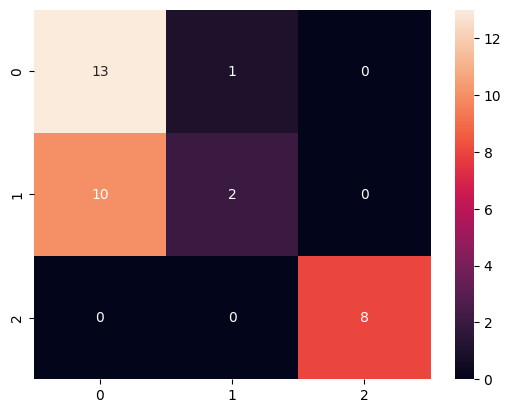

In [71]:
import seaborn as sns
sns.heatmap(c_matrix, annot=True);

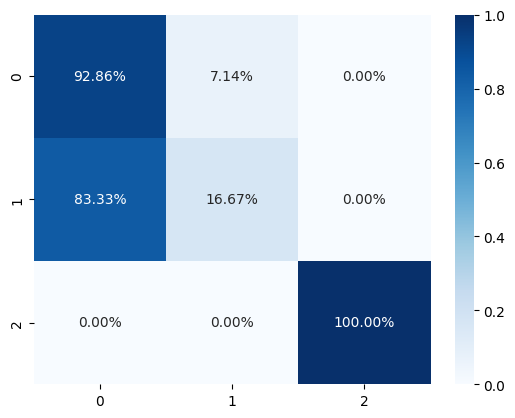

In [72]:
sns.heatmap(confusion_matrix(Y_test, predictions, normalize='true'), annot=True, 
            fmt='.2%', cmap='Blues');

In [76]:
from sklearn.metrics import multilabel_confusion_matrix, precision_score, recall_score, f1_score

multilabel_confusion_matrix(Y_test, predictions)

array([[[10, 10],
        [ 1, 13]],

       [[21,  1],
        [10,  2]],

       [[26,  0],
        [ 0,  8]]])

[Nice confusion matrix catalog visuals examples](https://medium.com/@dtuk81/confusion-matrix-visualization-fc31e3f30fea)

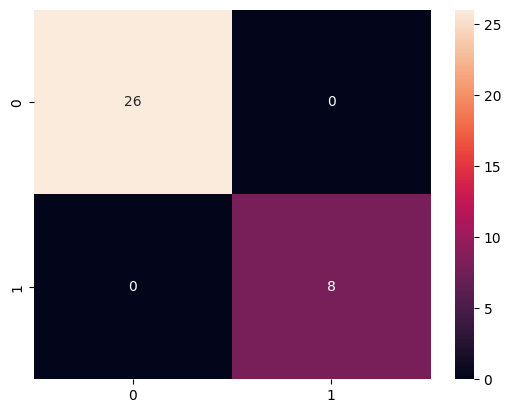

In [74]:
sns.heatmap(multilabel_confusion_matrix(Y_test, predictions)[2], annot=True);

In [77]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, predictions))

              precision    recall  f1-score   support

           0       0.57      0.93      0.70        14
           1       0.67      0.17      0.27        12
           2       1.00      1.00      1.00         8

    accuracy                           0.68        34
   macro avg       0.74      0.70      0.66        34
weighted avg       0.70      0.68      0.62        34



# Clasificación de nuevos registros

In [78]:
X_new = pd.DataFrame({'duracion': [8],
                     'paginas': [5],
                     'acciones': [5],
                     'valor': [2]})
X_new

,duracion,paginas,acciones,valor
0,8,5,5,2


In [79]:
X_new.values

array([[8, 5, 5, 2]])

In [80]:
model.predict(X_new.values)

array([2])

In [82]:
np.round(model.predict_proba(X_new.values), 2)

array([[0., 0., 1.]])